# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [12]:
!git clone https://github.com/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP

fatal: destination path 'Flyrank-ML-INTERNSHIP' already exists and is not an empty directory.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


This section converts the validated modeling approach into a practical action queue.

The queue is a decision-support artifact rather than an automated content-management system.
Pages are ranked using the model's estimated probability of the `down` class together with
observable content-performance signals.

Each queued page receives:
- a priority rank,
- a proposed action,
- one or more reason codes,
- and supporting signals that a human reviewer can inspect.

The purpose is to identify pages that may deserve review first, not to automatically
approve, edit, redirect, delete, or publish content.


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
from pathlib import Path

REPO_DIR = Path("/content/Flyrank-ML-INTERNSHIP")

DATA_PATH = REPO_DIR / "data" / "raw" / "content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Target distribution:")
print(df["trend_direction"].value_counts())


Dataset shape: (30000, 44)
Target distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


In [14]:
target = "trend_direction"

features = [
    "content_age_days",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[features]
y = df[target]

print("Features:", len(features))
print("Rows:", len(df))

Features: 26
Rows: 30000


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

model.fit(X, y)

print("Decision Tree trained on the full dataset.")

Decision Tree trained on the full dataset.


In [16]:
class_names = model.named_steps["tree"].classes_

print("Model classes:", class_names)

down_index = list(class_names).index("down")

df["down_probability"] = model.predict_proba(X)[:, down_index]

df["predicted_trend"] = model.predict(X)

print(
    df["down_probability"].describe()
)

Model classes: ['down' 'flat' 'new' 'stable' 'up']
count    30000.000000
mean         0.542067
std          0.291403
min          0.000000
25%          0.437637
50%          0.716741
75%          0.716741
max          0.991263
Name: down_probability, dtype: float64


In [17]:
def build_reason_codes(row):
    reasons = []

    # Recent visibility decline
    if (
        pd.notna(row["impressions_last_30d"]) and
        pd.notna(row["impressions_prev_30d"]) and
        row["impressions_prev_30d"] > 0
    ):
        impression_change = (
            row["impressions_last_30d"] /
            row["impressions_prev_30d"]
        )

        if impression_change < 0.70:
            reasons.append("IMPRESSION_DECLINE")

    # Older content
    if pd.notna(row["content_age_days"]) and row["content_age_days"] >= 360:
        reasons.append("CONTENT_AGE_360_PLUS")

    elif pd.notna(row["content_age_days"]) and row["content_age_days"] >= 270:
        reasons.append("CONTENT_AGE_270_PLUS")

    # Search opportunity
    if (
        pd.notna(row["avg_position"]) and
        pd.notna(row["ctr"]) and
        row["avg_position"] <= 10 and
        row["ctr"] < 0.05
    ):
        reasons.append("HIGH_RANK_LOW_CTR")

    # Recent click decline
    if (
        pd.notna(row["clicks_last_30d"]) and
        pd.notna(row["clicks_prev_30d"]) and
        row["clicks_prev_30d"] > 0
    ):
        click_change = (
            row["clicks_last_30d"] /
            row["clicks_prev_30d"]
        )

        if click_change < 0.70:
            reasons.append("CLICK_DECLINE")

    if not reasons:
        reasons.append("MODEL_PRIORITY_ONLY")

    return "|".join(reasons)


df["reason_codes"] = df.apply(build_reason_codes, axis=1)

print(df["reason_codes"].value_counts().head(15))

reason_codes
IMPRESSION_DECLINE                                       5151
MODEL_PRIORITY_ONLY                                      4587
CONTENT_AGE_360_PLUS                                     3418
CONTENT_AGE_270_PLUS                                     2287
IMPRESSION_DECLINE|CLICK_DECLINE                         2227
HIGH_RANK_LOW_CTR                                        1835
IMPRESSION_DECLINE|HIGH_RANK_LOW_CTR                     1769
IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS                  1687
IMPRESSION_DECLINE|CONTENT_AGE_360_PLUS                  1363
CONTENT_AGE_270_PLUS|HIGH_RANK_LOW_CTR                   1325
CLICK_DECLINE                                             911
CONTENT_AGE_360_PLUS|CLICK_DECLINE                        708
IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS|CLICK_DECLINE     643
CONTENT_AGE_270_PLUS|CLICK_DECLINE                        480
IMPRESSION_DECLINE|CONTENT_AGE_360_PLUS|CLICK_DECLINE     455
Name: count, dtype: int64


In [18]:
def assign_action(row):
    reasons = row["reason_codes"]

    if "IMPRESSION_DECLINE" in reasons and "CONTENT_AGE_360_PLUS" in reasons:
        return "refresh_review"

    if "IMPRESSION_DECLINE" in reasons and "HIGH_RANK_LOW_CTR" in reasons:
        return "refresh_review"

    if "IMPRESSION_DECLINE" in reasons:
        return "performance_review"

    if "HIGH_RANK_LOW_CTR" in reasons:
        return "ctr_review"

    if "CONTENT_AGE_360_PLUS" in reasons:
        return "age_review"

    if row["predicted_trend"] == "down":
        return "performance_review"

    return "monitor"


df["proposed_action"] = df.apply(assign_action, axis=1)

print(df["proposed_action"].value_counts())

proposed_action
performance_review    15274
refresh_review         4408
age_review             4126
ctr_review             3493
monitor                2699
Name: count, dtype: int64


In [19]:
df["priority_score"] = df["down_probability"]

df = df.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

df["priority_rank"] = np.arange(1, len(df) + 1)

print(
    df[
        [
            "priority_rank",
            "content_id",
            "predicted_trend",
            "down_probability",
            "proposed_action",
            "reason_codes"
        ]
    ].head(20)
)

    priority_rank            content_id predicted_trend  down_probability  \
0               1  content_38112bdd0c6e            down          0.991263   
1               2  content_d4084a4bc775            down          0.991263   
2               3  content_304f48230142            down          0.991263   
3               4  content_829a902cef34            down          0.991263   
4               5  content_1817599482a7            down          0.991263   
5               6  content_934a2152f961            down          0.991263   
6               7  content_4e9c08766775            down          0.991263   
7               8  content_8d944a023366            down          0.991263   
8               9  content_c2623272bc49            down          0.991263   
9              10  content_149f5cd7e279            down          0.991263   
10             11  content_229d2a8714c7            down          0.991263   
11             12  content_690579420124            down          0.991263   

In [20]:
top20 = df.head(20).copy()

display(
    top20[
        [
            "priority_rank",
            "content_id",
            "content_age_days",
            "impressions_last_30d",
            "impressions_prev_30d",
            "clicks_last_30d",
            "clicks_prev_30d",
            "ctr",
            "avg_position",
            "down_probability",
            "predicted_trend",
            "proposed_action",
            "reason_codes"
        ]
    ]
)

,priority_rank,content_id,content_age_days,impressions_last_30d,impressions_prev_30d,clicks_last_30d,clicks_prev_30d,ctr,avg_position,down_probability,predicted_trend,proposed_action,reason_codes
0,1,content_38112bdd0c6e,124,404,1194,0,4,0.19,4.1,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
1,2,content_d4084a4bc775,147,617,1009,0,1,0.03,8.5,0.991263,down,refresh_review,IMPRESSION_DECLINE|HIGH_RANK_LOW_CTR|CLICK_DEC...
2,3,content_304f48230142,187,578,987,2,13,0.76,10.6,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
3,4,content_829a902cef34,125,441,1198,2,3,0.29,10.9,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
4,5,content_1817599482a7,286,391,914,0,1,0.03,15.1,0.991263,down,performance_review,IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS|CLICK_...
5,6,content_934a2152f961,103,287,1343,1,5,0.29,8.0,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
6,7,content_4e9c08766775,124,713,1947,5,3,0.24,29.3,0.991263,down,performance_review,IMPRESSION_DECLINE
7,8,content_8d944a023366,140,829,1690,8,4,0.37,8.7,0.991263,down,performance_review,IMPRESSION_DECLINE
8,9,content_c2623272bc49,125,482,1721,0,0,0.00,11.3,0.991263,down,performance_review,IMPRESSION_DECLINE
9,10,content_149f5cd7e279,139,411,1003,1,0,0.08,14.7,0.991263,down,performance_review,IMPRESSION_DECLINE


In [21]:
action_mix = (
    df["proposed_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

action_mix["percentage"] = (
    action_mix["count"] / len(df) * 100
).round(2)

display(action_mix)

,action,count,percentage
0,performance_review,15274,50.91
1,refresh_review,4408,14.69
2,age_review,4126,13.75
3,ctr_review,3493,11.64
4,monitor,2699,9.00


In [22]:
reason_mix = (
    df["reason_codes"]
    .str.split("|")
    .explode()
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_mix["percentage"] = (
    reason_mix["count"] / len(df) * 100
).round(2)

display(reason_mix)

,reason_code,count,percentage
0,IMPRESSION_DECLINE,14116,47.05
1,CONTENT_AGE_270_PLUS,6863,22.88
2,CONTENT_AGE_360_PLUS,6610,22.03
3,HIGH_RANK_LOW_CTR,6083,20.28
4,CLICK_DECLINE,5500,18.33
5,MODEL_PRIORITY_ONLY,4587,15.29


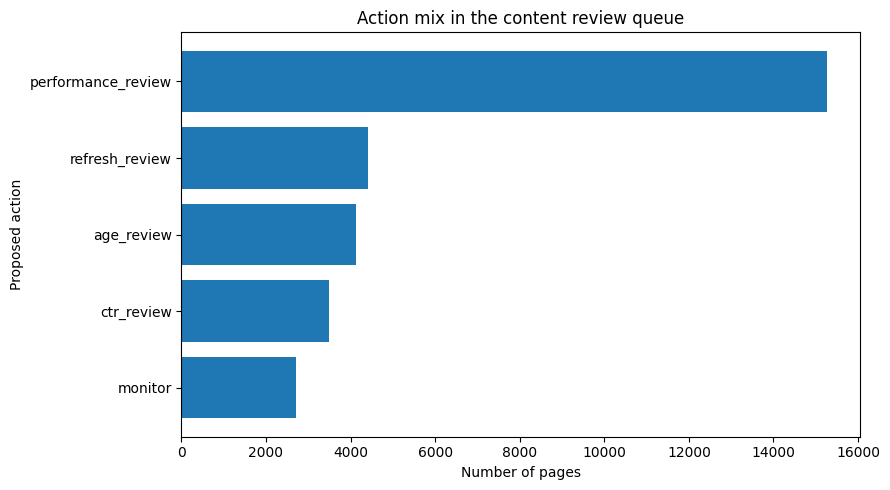

Saved: /content/Flyrank-ML-INTERNSHIP/work/figures/w07_action_mix.png


In [23]:
plt.figure(figsize=(9, 5))

action_mix_sorted = action_mix.sort_values(
    "count",
    ascending=True
)

plt.barh(
    action_mix_sorted["action"],
    action_mix_sorted["count"]
)

plt.xlabel("Number of pages")
plt.ylabel("Proposed action")
plt.title("Action mix in the content review queue")

plt.tight_layout()

action_fig_path = FIGURE_DIR / "w07_action_mix.png"

plt.savefig(
    action_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", action_fig_path)

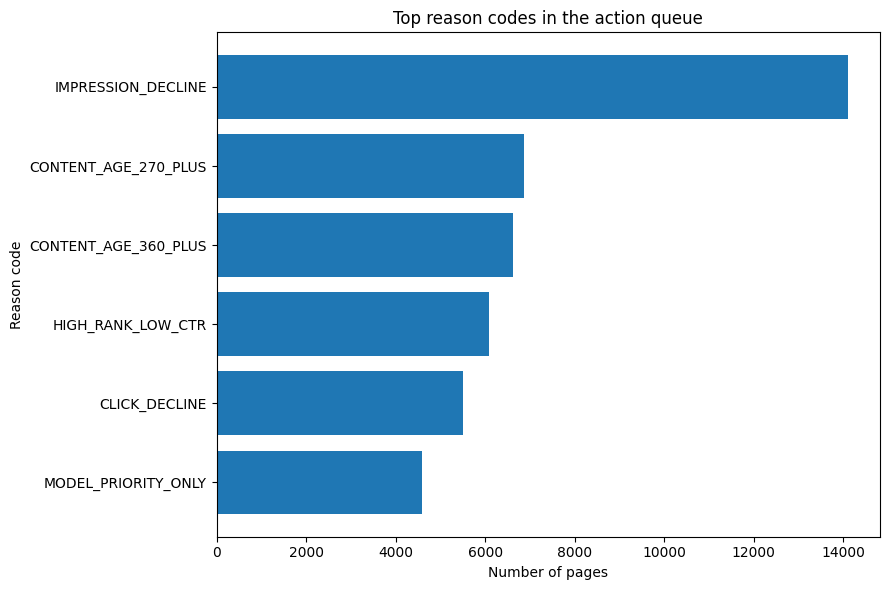

Saved: /content/Flyrank-ML-INTERNSHIP/work/figures/w07_reason_codes.png


In [24]:
plt.figure(figsize=(9, 6))

reason_plot = reason_mix.head(10).sort_values(
    "count",
    ascending=True
)

plt.barh(
    reason_plot["reason_code"],
    reason_plot["count"]
)

plt.xlabel("Number of pages")
plt.ylabel("Reason code")
plt.title("Top reason codes in the action queue")

plt.tight_layout()

reason_fig_path = FIGURE_DIR / "w07_reason_codes.png"

plt.savefig(
    reason_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", reason_fig_path)

In [25]:
queue_columns = [
    "priority_rank",
    "content_id",
    "priority_score",
    "down_probability",
    "predicted_trend",
    "proposed_action",
    "reason_codes",
    "content_age_days",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "ctr",
    "avg_position"
]

action_queue = df[queue_columns].copy()

queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported to:")
print(queue_path)

print("\nRows:", len(action_queue))
print("Columns:", len(action_queue.columns))

Queue exported to:
/content/Flyrank-ML-INTERNSHIP/work/outputs/w07_ranked_action_queue.csv

Rows: 30000
Columns: 14


### Interpretation

The ranked queue converts the validated modeling output into a practical review order.

The primary ranking signal is the model's estimated probability of the `down` class. Reason
codes are added from observable performance and content signals so that reviewers can inspect
why a page was prioritized.

The main proposed action is `refresh_review`, with additional actions for performance review,
CTR review, age review, or monitoring. These actions are recommendations for human review,
not automatic changes to content.

The queue should be interpreted conservatively. The Week-6 validation audit measured 63.1%
accuracy and a 0.6187 macro F1 under client-grouped validation. In addition, several
performance features are timing-sensitive because they are closely related to the construction
of `trend_direction`. Therefore, the queue is a research and decision-support artifact rather
than evidence of production-level predictive performance.

In [27]:
def build_reason_codes(row):
    reasons = []

    # Recent impression decline
    if (
        pd.notna(row["impressions_last_30d"]) and
        pd.notna(row["impressions_prev_30d"]) and
        row["impressions_prev_30d"] > 0
    ):
        impression_ratio = (
            row["impressions_last_30d"] /
            row["impressions_prev_30d"]
        )

        if impression_ratio < 0.70:
            reasons.append("IMPRESSION_DECLINE")

    # Older content
    if (
        pd.notna(row["content_age_days"]) and
        row["content_age_days"] >= 360
    ):
        reasons.append("CONTENT_AGE_360_PLUS")

    elif (
        pd.notna(row["content_age_days"]) and
        row["content_age_days"] >= 270
    ):
        reasons.append("CONTENT_AGE_270_PLUS")

    # Ranking opportunity with low CTR
    if (
        pd.notna(row["avg_position"]) and
        pd.notna(row["ctr"]) and
        row["avg_position"] <= 10 and
        row["ctr"] < 0.05
    ):
        reasons.append("HIGH_RANK_LOW_CTR")

    # Recent click decline
    if (
        pd.notna(row["clicks_last_30d"]) and
        pd.notna(row["clicks_prev_30d"]) and
        row["clicks_prev_30d"] > 0
    ):
        click_ratio = (
            row["clicks_last_30d"] /
            row["clicks_prev_30d"]
        )

        if click_ratio < 0.70:
            reasons.append("CLICK_DECLINE")

    # Fallback
    if not reasons:
        reasons.append("MODEL_PRIORITY_ONLY")

    return "|".join(reasons)


df["reason_codes"] = df.apply(build_reason_codes, axis=1)

print("Reason codes created.")
print()
print(df["reason_codes"].value_counts().head(15))

Reason codes created.

reason_codes
IMPRESSION_DECLINE                                       5151
MODEL_PRIORITY_ONLY                                      4587
CONTENT_AGE_360_PLUS                                     3418
CONTENT_AGE_270_PLUS                                     2287
IMPRESSION_DECLINE|CLICK_DECLINE                         2227
HIGH_RANK_LOW_CTR                                        1835
IMPRESSION_DECLINE|HIGH_RANK_LOW_CTR                     1769
IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS                  1687
IMPRESSION_DECLINE|CONTENT_AGE_360_PLUS                  1363
CONTENT_AGE_270_PLUS|HIGH_RANK_LOW_CTR                   1325
CLICK_DECLINE                                             911
CONTENT_AGE_360_PLUS|CLICK_DECLINE                        708
IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS|CLICK_DECLINE     643
CONTENT_AGE_270_PLUS|CLICK_DECLINE                        480
IMPRESSION_DECLINE|CONTENT_AGE_360_PLUS|CLICK_DECLINE     455
Name: count, dtype: int64


In [28]:
df["priority_score"] = df["down_probability"]

df = df.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

df["priority_rank"] = np.arange(1, len(df) + 1)

print("Queue ranked successfully.")
print("Total pages:", len(df))

Queue ranked successfully.
Total pages: 30000


In [29]:
top20 = df.head(20).copy()

display(
    top20[
        [
            "priority_rank",
            "content_id",
            "content_age_days",
            "impressions_last_30d",
            "impressions_prev_30d",
            "clicks_last_30d",
            "clicks_prev_30d",
            "ctr",
            "avg_position",
            "down_probability",
            "predicted_trend",
            "proposed_action",
            "reason_codes"
        ]
    ]
)

,priority_rank,content_id,content_age_days,impressions_last_30d,impressions_prev_30d,clicks_last_30d,clicks_prev_30d,ctr,avg_position,down_probability,predicted_trend,proposed_action,reason_codes
0,1,content_11ba829169ac,329,726,1907,2,2,0.10,3.0,0.991263,down,performance_review,IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS
1,2,content_ad39efde2677,174,188,1243,0,3,0.12,27.6,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
2,3,content_e901090a30db,257,780,966,0,0,0.03,11.0,0.991263,down,performance_review,MODEL_PRIORITY_ONLY
3,4,content_eea0194e50eb,126,752,1071,2,3,0.28,5.1,0.991263,down,performance_review,CLICK_DECLINE
4,5,content_e68cec9bff9b,144,732,1326,0,0,0.03,7.3,0.991263,down,refresh_review,IMPRESSION_DECLINE|HIGH_RANK_LOW_CTR
5,6,content_510ffd8f051c,90,696,3398,4,6,0.24,31.0,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
6,7,content_9115c60a5526,118,612,1472,5,1,0.41,9.2,0.991263,down,performance_review,IMPRESSION_DECLINE
7,8,content_ff6d42b2e848,117,754,2182,0,4,0.11,5.1,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
8,9,content_559cda54c5cc,104,554,1768,1,3,0.28,13.0,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE
9,10,content_d43654617552,223,613,1242,0,3,0.11,34.8,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE


In [30]:
action_mix = (
    df["proposed_action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

action_mix["percentage"] = (
    action_mix["count"] / len(df) * 100
).round(2)

display(action_mix)

,action,count,percentage
0,performance_review,15274,50.91
1,refresh_review,4408,14.69
2,age_review,4126,13.75
3,ctr_review,3493,11.64
4,monitor,2699,9.00


In [31]:
reason_mix = (
    df["reason_codes"]
    .str.split("|")
    .explode()
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_mix["percentage"] = (
    reason_mix["count"] / len(df) * 100
).round(2)

display(reason_mix)

,reason_code,count,percentage
0,IMPRESSION_DECLINE,14116,47.05
1,CONTENT_AGE_270_PLUS,6863,22.88
2,CONTENT_AGE_360_PLUS,6610,22.03
3,HIGH_RANK_LOW_CTR,6083,20.28
4,CLICK_DECLINE,5500,18.33
5,MODEL_PRIORITY_ONLY,4587,15.29


In [32]:
from pathlib import Path

REPO_DIR = Path("/content/Flyrank-ML-INTERNSHIP")

OUTPUT_DIR = REPO_DIR / "work" / "outputs"
FIGURE_DIR = REPO_DIR / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs:", OUTPUT_DIR)
print("Figures:", FIGURE_DIR)

Outputs: /content/Flyrank-ML-INTERNSHIP/work/outputs
Figures: /content/Flyrank-ML-INTERNSHIP/work/figures


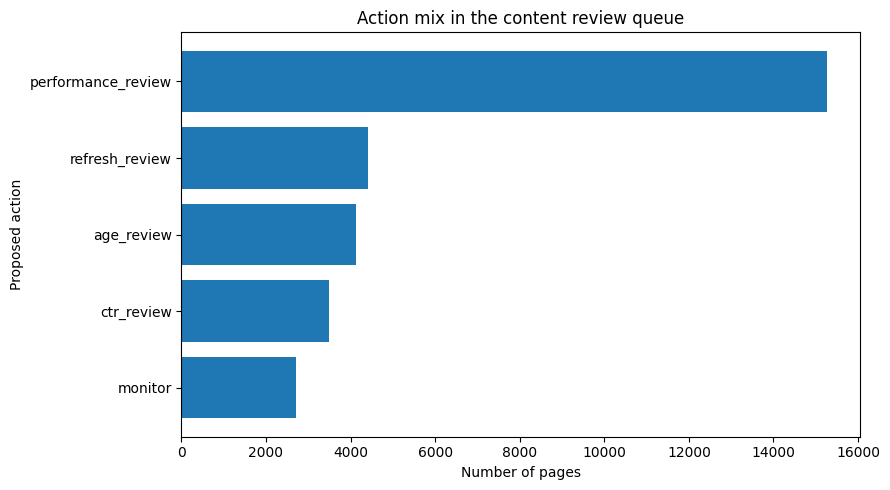

Saved: /content/Flyrank-ML-INTERNSHIP/work/figures/w07_action_mix.png


In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plot_data = action_mix.sort_values(
    "count",
    ascending=True
)

plt.barh(
    plot_data["action"],
    plot_data["count"]
)

plt.xlabel("Number of pages")
plt.ylabel("Proposed action")
plt.title("Action mix in the content review queue")

plt.tight_layout()

action_fig_path = FIGURE_DIR / "w07_action_mix.png"

plt.savefig(
    action_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", action_fig_path)

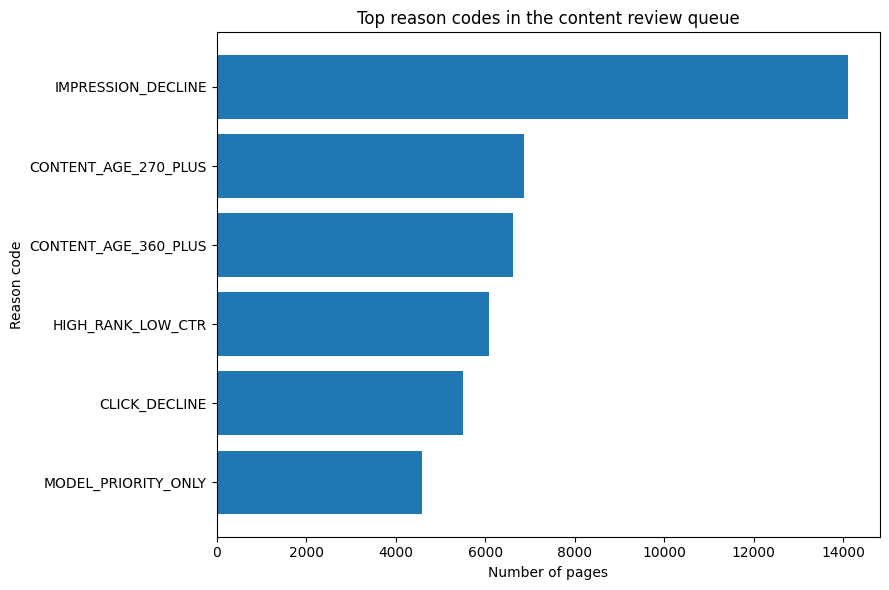

Saved: /content/Flyrank-ML-INTERNSHIP/work/figures/w07_reason_codes.png


In [34]:
plt.figure(figsize=(9, 6))

plot_reason = reason_mix.head(10).sort_values(
    "count",
    ascending=True
)

plt.barh(
    plot_reason["reason_code"],
    plot_reason["count"]
)

plt.xlabel("Number of pages")
plt.ylabel("Reason code")
plt.title("Top reason codes in the content review queue")

plt.tight_layout()

reason_fig_path = FIGURE_DIR / "w07_reason_codes.png"

plt.savefig(
    reason_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", reason_fig_path)

In [36]:
queue_columns = [
    "priority_rank",
    "content_id",
    "priority_score",
    "down_probability",
    "predicted_trend",
    "proposed_action",
    "reason_codes",
    "content_age_days",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "ctr",
    "avg_position"
]

action_queue = df[queue_columns].copy()

queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"

action_queue.to_csv(
    queue_path,
    index=False
)

print("Queue exported successfully.")
print(queue_path)
print("Rows:", len(action_queue))

Queue exported successfully.
/content/Flyrank-ML-INTERNSHIP/work/outputs/w07_ranked_action_queue.csv
Rows: 30000


In [37]:
check_queue = pd.read_csv(queue_path)

print("Export verification")
print("-------------------")
print("File exists:", queue_path.exists())
print("Rows:", len(check_queue))
print("Columns:", len(check_queue.columns))

display(check_queue.head(10))

Export verification
-------------------
File exists: True
Rows: 30000
Columns: 14


,priority_rank,content_id,priority_score,down_probability,predicted_trend,proposed_action,reason_codes,content_age_days,impressions_last_30d,impressions_prev_30d,clicks_last_30d,clicks_prev_30d,ctr,avg_position
0,1,content_11ba829169ac,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE|CONTENT_AGE_270_PLUS,329,726,1907,2,2,0.10,3.0
1,2,content_ad39efde2677,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE,174,188,1243,0,3,0.12,27.6
2,3,content_e901090a30db,0.991263,0.991263,down,performance_review,MODEL_PRIORITY_ONLY,257,780,966,0,0,0.03,11.0
3,4,content_eea0194e50eb,0.991263,0.991263,down,performance_review,CLICK_DECLINE,126,752,1071,2,3,0.28,5.1
4,5,content_e68cec9bff9b,0.991263,0.991263,down,refresh_review,IMPRESSION_DECLINE|HIGH_RANK_LOW_CTR,144,732,1326,0,0,0.03,7.3
5,6,content_510ffd8f051c,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE,90,696,3398,4,6,0.24,31.0
6,7,content_9115c60a5526,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE,118,612,1472,5,1,0.41,9.2
7,8,content_ff6d42b2e848,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE,117,754,2182,0,4,0.11,5.1
8,9,content_559cda54c5cc,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE,104,554,1768,1,3,0.28,13.0
9,10,content_d43654617552,0.991263,0.991263,down,performance_review,IMPRESSION_DECLINE|CLICK_DECLINE,223,613,1242,0,3,0.11,34.8


### Section 1 interpretation

The ranked queue converts the modeling output into a practical review order. Pages are ranked
using the model's estimated probability of the `down` class, while transparent reason codes
provide additional signals that a reviewer can inspect.

The proposed actions are intentionally framed as review actions rather than automatic content
changes. `refresh_review` identifies pages that may warrant closer inspection because of
combined decline, age, or search-opportunity signals. Other pages may receive a performance,
CTR, age, or monitoring recommendation.

The queue is a decision-support artifact, not a production automation system. The Week-6 audit
measured 63.1% accuracy and 0.6187 macro F1 under client-grouped validation. Several historical
performance features are also timing-sensitive because they are closely related to the
construction of `trend_direction`. Therefore, the ranked queue should be reviewed by a human
before any content action is taken.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
## Intended use

The action playbook is intended to support human prioritization of content that may deserve
review or refresh.

Its main use is to help a content or SEO reviewer answer:

1. Which pages should be reviewed first?
2. What observable signals caused a page to enter the queue?
3. What type of review may be appropriate?
4. Which pages can remain in a monitoring group?

The ranked queue is therefore a decision-support artifact. It is designed to make review
prioritization more systematic and reproducible, rather than replacing editorial or SEO
judgment.

The queue can be used for research, prioritization, and demonstration of a possible content
refresh workflow. It is not intended to operate as a production content-management system.
## What the model score means

The `down_probability` value represents the model's estimated probability of the `down`
class under the modeling setup used in this notebook.

A higher value means that the model assigns greater probability to the `down` class and
therefore gives the page higher priority in the review queue.

The score should not be interpreted as:

- the probability that refreshing the page will improve performance;
- the probability that a page is objectively "bad";
- a causal estimate of the benefit of refreshing;
- a guaranteed prediction of future traffic;
- or an instruction to automatically change the page.

The score is a ranking signal for human review.
## Limits

Several limitations constrain how the action playbook should be interpreted.

### 1. Validation performance is moderate

The client-grouped validation produced approximately 63.1% accuracy and 0.6187 macro F1.
This is useful evidence that the model contains signal, but it is not strong enough to justify
fully autonomous content decisions.

### 2. Generalization is uncertain

The grouped validation was designed to test performance on clients not seen during training.
The lower grouped performance compared with the random split indicates that random validation
can give a more optimistic estimate of generalization.

### 3. Timing-sensitive features

Several performance variables, including recent impressions, clicks, sessions, CTR, and
average position, are closely related to the construction of the target trend label.

This means the model should not be interpreted as evidence of a clean causal forecasting
system. These features may be useful for prioritization, but their relationship with the
target requires careful interpretation.

### 4. The queue does not measure intervention impact

The current workflow does not estimate whether a specific refresh will improve traffic,
rankings, clicks, or conversions.

A page can therefore be correctly prioritized for review without the eventual refresh being
successful.

### 5. No causal claim

The action playbook identifies associations and prioritization signals. It does not establish
that content age, impressions, clicks, CTR, or any other feature causes a decline.

### 6. Research rather than production

The current queue should be treated as a research artifact and prototype workflow. It has not
been demonstrated to operate safely as an automated production decision system.

## What the system can do

Within its intended scope, the workflow can:

- rank pages for human review;
- identify pages with higher model-based `down` priority;
- attach transparent reason codes;
- group pages into proposed review actions;
- provide supporting performance and content signals;
- produce a reproducible CSV queue;
- and provide summary figures for research reporting.
## What the system cannot reliably do

The workflow cannot reliably:

- guarantee that a page will decline;
- guarantee that a refresh will improve performance;
- determine the exact editorial changes required;
- estimate the financial return of a refresh;
- automatically decide that content should be deleted;
- automatically redirect or consolidate URLs;
- automatically publish rewritten content;
- determine whether a page violates editorial, legal, medical, financial, or brand requirements;
- or replace expert SEO and editorial review.


## Practical use boundary

The intended workflow is:

**Model ranking → human inspection → evidence review → editorial/SEO decision → action → monitoring**

The model should not bypass the human inspection stage.

The output is therefore best understood as a prioritized research queue rather than an
autonomous recommendation engine.
| Area | Current limitation | Practical implication |
|---|---|---|
| Predictive performance | Grouped validation is moderate | Use for prioritization, not autonomous decisions |
| Generalization | Client-level generalization is uncertain | Revalidate before broader deployment |
| Feature timing | Some performance features are timing-sensitive | Avoid causal or forecasting claims |
| Intervention impact | No treatment-effect estimate | Refresh success must be evaluated separately |
| Editorial judgment | Model cannot assess content quality directly | Human review remains required |
| Production readiness | Prototype/research workflow | Do not automate irreversible actions |

## Paper-ready statement

The resulting action playbook is designed as a human-in-the-loop prioritization framework.
It translates model output into ranked review candidates while preserving human control over
content decisions. Because validation performance is moderate, client-level generalization
remains uncertain, and several performance features are timing-sensitive, the framework is
presented as a research prototype rather than a production automation system.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*
## Human-in-the-loop review workflow

The ranked queue is not an automatic action list. Every queued page must pass through human
review before any content change is made.

The recommended workflow is:

**1. Model prioritization → 2. Signal inspection → 3. Content review → 4. SEO/context review
→ 5. Human decision → 6. Action → 7. Monitor outcome**

The model determines which pages deserve attention first. The reviewer determines whether
the proposed action is appropriate.
## Reviewer checklist

For each page selected from the queue, the reviewer should check:

### A. Performance evidence

- Is the recent performance decline visible in the underlying data?
- Is the decline large enough to justify attention?
- Are impressions, clicks, CTR, and average position consistent with the recommendation?
- Could the observed change be caused by seasonality or another external factor?

### B. Content condition

- How old is the content?
- Has the topic or search intent changed?
- Is the information still accurate?
- Are important facts, examples, links, or references outdated?
- Does the page still satisfy the likely search intent?

### C. Search opportunity

- Is the page ranking for meaningful queries?
- Is there evidence of an opportunity to improve CTR or relevance?
- Is the page competing with newer or more relevant content?

### D. Business and editorial context

- Is the page strategically important?
- Does it support an important topic or business goal?
- Are there brand, legal, compliance, or editorial requirements?
- Are there dependencies on other pages or campaigns?

### E. Final human decision

The reviewer should choose one of:

- **Approve review/refresh**
- **Monitor**
- **Defer**
- **Reject recommendation**
- **Escalate for specialist review**

The model's proposed action should never be treated as a mandatory decision.

## Archetype → action mapping

| Content archetype / signal pattern | Suggested review action | Human question |
|---|---|---|
| Older content + impression decline | Refresh review | Is the content outdated or no longer aligned with search intent? |
| Impression decline + strong ranking but low CTR | CTR review | Does the title/snippet accurately communicate the page value? |
| Impression decline without a clear content-age signal | Performance review | Is the decline real and what external factors could explain it? |
| Older content without clear decline | Age review | Is there a reason to update the page proactively? |
| High model priority without strong supporting signals | Manual investigation | Is there enough independent evidence to justify action? |
| Stable or improving page | Monitor | Is intervention actually necessary? |

## Reason-code interpretation

Reason codes are intended to make the queue easier to inspect.

| Reason code | Interpretation | Reviewer should verify |
|---|---|---|
| `IMPRESSION_DECLINE` | Recent impressions are substantially below the previous period | Whether the decline is genuine and meaningful |
| `CONTENT_AGE_360_PLUS` | Content is at least 360 days old | Whether the information is actually outdated |
| `CONTENT_AGE_270_PLUS` | Content is 270–359 days old | Whether an update would provide meaningful value |
| `HIGH_RANK_LOW_CTR` | Relatively strong ranking with comparatively low CTR | Search-result presentation and intent alignment |
| `CLICK_DECLINE` | Recent clicks are substantially below the previous period | Whether the decline reflects a meaningful change |
| `MODEL_PRIORITY_ONLY` | Model gives the page high priority without a matching explicit rule | Additional evidence before considering action |
## No-go list: actions that should NOT be automated

The following actions should not be automatically executed from the model output:

1. **Do not automatically publish rewritten content.**

2. **Do not automatically delete pages.**

3. **Do not automatically redirect URLs.**

4. **Do not automatically merge or consolidate content.**

5. **Do not automatically change canonical URLs.**

6. **Do not automatically change robots or indexing directives.**

7. **Do not automatically change titles, metadata, or page content without review.**

8. **Do not automatically infer that a page is low quality from a high `down_probability`.**

9. **Do not automatically claim that refreshing a page will improve traffic or rankings.**

10. **Do not automatically make legal, compliance, medical, financial, or brand-sensitive
content decisions.**

11. **Do not automatically spend significant editorial resources solely because a page has a
high model score.**

12. **Do not automatically retrain or redeploy the model based on a single unusual observation.**


## Why human review is required

The model captures statistical patterns in the available data, but it does not observe all
factors that influence whether a content intervention is appropriate.

In particular, the model does not directly evaluate:

- factual accuracy;
- content quality;
- search intent;
- editorial standards;
- brand requirements;
- legal or compliance requirements;
- seasonality;
- major search-engine changes;
- business priorities;
- or the expected return from a specific intervention.

The Week-6 validation audit also found that several performance features are timing-sensitive
relative to the construction of the target label. Therefore, model output should be treated as
a prioritization signal rather than an autonomous decision.
## Human decision matrix

| Model / signal outcome | Human review result | Recommended next step |
|---|---|---|
| High priority + strong supporting evidence | Confirmed opportunity | Approve refresh investigation |
| High priority + weak supporting evidence | Uncertain | Defer or investigate further |
| High priority + important business page | Specialist review needed | Escalate |
| Low priority + clear independent issue | Model missed signal | Human can override model |
| Stable/improving page | No immediate concern | Monitor |
| Conflicting signals | Unclear | Do not automate; investigate manually |


## Suggested human-review record

For each reviewed page, the reviewer should record:

- `content_id`
- `priority_rank`
- `model_priority_score`
- `proposed_action`
- `reason_codes`
- `review_decision`
- `reviewer_notes`
- `approved_action`
- `review_date`
- `follow_up_date`

This information would allow future analysis of whether model-prioritized pages actually led to
useful content actions.
## Paper-ready summary

The action playbook uses a human-in-the-loop design. Model output determines review priority,
while reviewers retain responsibility for interpreting the evidence and approving any content
action. Reason codes provide an interpretable bridge between model ranking and manual
inspection.

Irreversible or high-risk actions, including deletion, redirects, publication, indexing
changes, and sensitive editorial decisions, are explicitly excluded from automation.

This design limits the system's role to prioritization and preserves expert judgment where
the available data and model performance are insufficient to support autonomous decisions.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*
## Monitoring approach

The action playbook should be monitored at three levels:

1. **Data monitoring** — whether the incoming data still resembles the data used to build
   the model.
2. **Model monitoring** — whether predictive performance remains acceptable when labels become
   available.
3. **Action monitoring** — whether the recommendations are useful to human reviewers and
   whether the resulting actions produce meaningful outcomes.

These checks are intended as lightweight research-prototype monitoring rules. They are not a
production monitoring infrastructure.
## 4.1 Data monitoring

Before relying on a new queue, check for:

- missing-value increases;
- unexpected feature ranges;
- unexpected category values;
- changes in the distribution of `trend_direction`;
- unusual changes in recent performance variables;
- and schema changes.

A major data-quality problem should pause the action workflow rather than being silently
passed into the model.

In [38]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Basic data-quality monitoring

monitoring_summary = pd.DataFrame({
    "check": [
        "row_count",
        "missing_values",
        "target_available",
        "duplicate_content_ids"
    ],
    "value": [
        len(df),
        int(df[features].isna().sum().sum()),
        df[target].notna().all(),
        int(df["content_id"].duplicated().sum())
    ]
})

display(monitoring_summary)


,check,value
0,row_count,30000
1,missing_values,22927
2,target_available,True
3,duplicate_content_ids,0


In [39]:
missingness = (
    df[features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percentage")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(missingness.head(15))

,feature,missing_percentage
0,word_count,25.663333
1,char_count,25.663333
2,cpc,8.226667
3,search_volume,8.226667
4,competition,8.226667
5,scroll_rate,0.416667
6,impressions_90d,0.000000
7,clicks_90d,0.000000
8,pageviews_90d,0.000000
9,content_age_days,0.000000


## Data-quality triggers

The following thresholds are proposed as practical review triggers:

| Trigger | Threshold | Response |
|---|---:|---|
| New feature missingness | >10 percentage-point increase | Investigate before generating queue |
| Duplicate content IDs | Any unexpected duplicates | Investigate data pipeline |
| Missing target labels | >5% when labels are expected | Do not use for performance evaluation |
| Unexpected schema | Any required feature missing | Stop and investigate |
| Extreme distribution change | Material shift in important features | Investigate before relying on ranking |
## 4.2 Model-performance monitoring

When future labeled data becomes available, evaluate the model using the same validation
principles used in the audit.

The most important metrics are:

- accuracy;
- macro precision;
- macro recall;
- macro F1;
- and per-class performance.

Macro F1 should receive particular attention because the target classes are imbalanced and
performance on minority classes can be hidden by overall accuracy.

The client-grouped evaluation should remain the preferred validation design when assessing
generalization to unseen clients.

## Retrain / investigation triggers

Retraining should not happen automatically after a single poor observation.

A retraining investigation should be considered when one or more of the following occurs:

### Trigger 1 — Sustained performance degradation

If macro F1 falls materially below the validated reference level across repeated evaluations,
investigate the cause and consider retraining.

Reference point from the current audit:

**Client-grouped macro F1 = 0.6187**

This value is a reference baseline, not a guaranteed production threshold.

### Trigger 2 — Distribution shift

If important input features show substantial distribution changes compared with the training
data, investigate whether the model remains appropriate.

### Trigger 3 — Label or business-process change

If the definition or construction of `trend_direction` changes, the existing model should not
be assumed to remain valid.

### Trigger 4 — Feature pipeline change

If important input features are redefined, removed, or calculated differently, rerun the
validation workflow before using the model.

### Trigger 5 — Repeated human disagreement

If reviewers frequently reject the model's proposed priorities, investigate whether the model
is ranking the wrong pages or whether the action rules need revision.

### Trigger 6 — Monitoring failure

If data-quality checks fail consistently, pause queue generation until the underlying issue is
understood.
## What should NOT trigger automatic retraining

The following events alone should not automatically trigger retraining:

- one unusual page;
- one poor prediction;
- one rejected recommendation;
- a temporary traffic spike;
- a single missing value;
- a single unusual client;
- or a short-term change in one metric.

These observations should first be investigated for data-quality problems, seasonality,
external events, or other explanations.
## 4.3 Action and outcome monitoring

Model accuracy alone does not determine whether the action playbook is useful.

For reviewed pages, record:

- whether the recommendation was accepted or rejected;
- which action was actually taken;
- whether the page was refreshed;
- the date of the intervention;
- impressions before and after the intervention;
- clicks before and after the intervention;
- CTR before and after the intervention;
- average position before and after the intervention;
- and reviewer comments.

This allows future analysis of whether model-prioritized pages were associated with useful
content decisions.

However, before/after changes should not automatically be interpreted as causal evidence of
the refresh effect. A controlled or quasi-experimental evaluation would be required for a
stronger intervention-impact claim.


## Monitoring checklist

| Monitoring layer | What to check | Trigger | Response |
|---|---|---|---|
| Data quality | Missingness | >10 percentage-point increase | Investigate |
| Data quality | Schema | Required feature missing | Pause workflow |
| Data quality | Duplicates | Unexpected duplicates | Investigate |
| Distribution | Important feature distributions | Material shift | Revalidate |
| Model | Macro F1 | Sustained degradation | Investigate/retrain |
| Model | Minority-class recall | Sustained deterioration | Investigate |
| Labels | Target definition | Definition changes | Rebuild/revalidate |
| Actions | Reviewer acceptance | Repeated disagreement | Review rules/model |
| Outcomes | Post-action metrics | Unexpected results | Investigate |

In [40]:
validation_reference = pd.DataFrame({
    "validation_design": [
        "Random stratified split",
        "Client-grouped split"
    ],
    "accuracy": [
        0.676,
        0.631
    ],
    "macro_f1": [
        0.6544,
        0.6187
    ]
})

display(validation_reference)

,validation_design,accuracy,macro_f1
0,Random stratified split,0.676,0.6544
1,Client-grouped split,0.631,0.6187


### Monitoring interpretation

The client-grouped result is the more conservative reference because it evaluates performance
on clients excluded from training.

The current reference values are:

- Accuracy: **0.631**
- Macro F1: **0.6187**

Future evaluations should use a comparable validation design so that changes in performance
can be interpreted consistently.

A drop in performance should trigger investigation rather than automatic retraining. The
cause may be data drift, label changes, feature-pipeline changes, or other changes in the
underlying problem.

In [41]:
print("Week-7 monitoring reference")
print("---------------------------")
print(f"Rows in current queue dataset: {len(df):,}")
print(f"Number of model features: {len(features)}")
print(f"Total missing feature values: {int(df[features].isna().sum().sum()):,}")
print(f"Duplicate content IDs: {int(df['content_id'].duplicated().sum()):,}")
print()
print("Validated reference:")
print("Client-grouped accuracy: 0.631")
print("Client-grouped macro F1: 0.6187")

Week-7 monitoring reference
---------------------------
Rows in current queue dataset: 30,000
Number of model features: 26
Total missing feature values: 22,927
Duplicate content IDs: 0

Validated reference:
Client-grouped accuracy: 0.631
Client-grouped macro F1: 0.6187


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*
## Export design

This section saves the main outputs of the action playbook for reuse in the research paper.

The ranked queue is exported to `work/outputs/` and is intentionally treated as a generated
artifact rather than a version-controlled data file.

Reusable figures are exported to `work/figures/` so that they can be committed to the
repository and reused in the paper.

The notebook is the reproducible source for regenerating the queue.

In [42]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from pathlib import Path

REPO_DIR = Path("/content/Flyrank-ML-INTERNSHIP")

OUTPUT_DIR = REPO_DIR / "work" / "outputs"
FIGURE_DIR = REPO_DIR / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)


Output directory: /content/Flyrank-ML-INTERNSHIP/work/outputs
Figure directory: /content/Flyrank-ML-INTERNSHIP/work/figures


In [43]:
queue_columns = [
    "priority_rank",
    "content_id",
    "priority_score",
    "down_probability",
    "predicted_trend",
    "proposed_action",
    "reason_codes",
    "content_age_days",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "ctr",
    "avg_position"
]

paper_queue = df[queue_columns].copy()

queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"

paper_queue.to_csv(
    queue_path,
    index=False
)

print("Saved:", queue_path)
print("Rows:", len(paper_queue))
print("Columns:", len(paper_queue.columns))

Saved: /content/Flyrank-ML-INTERNSHIP/work/outputs/w07_ranked_action_queue.csv
Rows: 30000
Columns: 14


In [44]:
action_summary_path = OUTPUT_DIR / "w07_action_summary.csv"

action_mix.to_csv(
    action_summary_path,
    index=False
)

print("Saved:", action_summary_path)

display(action_mix)

Saved: /content/Flyrank-ML-INTERNSHIP/work/outputs/w07_action_summary.csv


,action,count,percentage
0,performance_review,15274,50.91
1,refresh_review,4408,14.69
2,age_review,4126,13.75
3,ctr_review,3493,11.64
4,monitor,2699,9.00


In [45]:
reason_summary_path = OUTPUT_DIR / "w07_reason_code_summary.csv"

reason_mix.to_csv(
    reason_summary_path,
    index=False
)

print("Saved:", reason_summary_path)

display(reason_mix)

Saved: /content/Flyrank-ML-INTERNSHIP/work/outputs/w07_reason_code_summary.csv


,reason_code,count,percentage
0,IMPRESSION_DECLINE,14116,47.05
1,CONTENT_AGE_270_PLUS,6863,22.88
2,CONTENT_AGE_360_PLUS,6610,22.03
3,HIGH_RANK_LOW_CTR,6083,20.28
4,CLICK_DECLINE,5500,18.33
5,MODEL_PRIORITY_ONLY,4587,15.29


In [46]:
validation_path = OUTPUT_DIR / "w07_validation_reference.csv"

validation_reference.to_csv(
    validation_path,
    index=False
)

print("Saved:", validation_path)

display(validation_reference)

Saved: /content/Flyrank-ML-INTERNSHIP/work/outputs/w07_validation_reference.csv


,validation_design,accuracy,macro_f1
0,Random stratified split,0.676,0.6544
1,Client-grouped split,0.631,0.6187


In [47]:
print("Week-7 generated outputs")
print("=" * 50)

for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f"{p.name:40s} {p.stat().st_size:,} bytes")

print()
print("Week-7 generated figures")
print("=" * 50)

for p in sorted(FIGURE_DIR.iterdir()):
    if p.is_file():
        print(f"{p.name:40s} {p.stat().st_size:,} bytes")

Week-7 generated outputs
w07_action_summary.csv                   142 bytes
w07_ranked_action_queue.csv              3,983,445 bytes
w07_reason_code_summary.csv              209 bytes
w07_validation_reference.csv             107 bytes

Week-7 generated figures
w07_action_mix.png                       59,773 bytes
w07_reason_codes.png                     77,889 bytes


In [48]:
exported_queue = pd.read_csv(
    OUTPUT_DIR / "w07_ranked_action_queue.csv"
)

assert len(exported_queue) == len(df)
assert exported_queue["priority_rank"].is_monotonic_increasing
assert exported_queue["content_id"].notna().all()
assert exported_queue["proposed_action"].notna().all()
assert exported_queue["reason_codes"].notna().all()

print("✓ Queue row count verified")
print("✓ Priority ranking verified")
print("✓ Content IDs verified")
print("✓ Proposed actions verified")
print("✓ Reason codes verified")
print()
print("Export checks passed.")

✓ Queue row count verified
✓ Priority ranking verified
✓ Content IDs verified
✓ Proposed actions verified
✓ Reason codes verified

Export checks passed.


In [49]:
required_figures = [
    FIGURE_DIR / "w07_action_mix.png",
    FIGURE_DIR / "w07_reason_codes.png"
]

for figure_path in required_figures:
    assert figure_path.exists(), f"Missing figure: {figure_path}"
    assert figure_path.stat().st_size > 0, f"Empty figure: {figure_path}"

print("All required Week-7 figures exist and are non-empty.")

All required Week-7 figures exist and are non-empty.


## Paper artifact map

| Artifact | Purpose in the paper |
|---|---|
| `w07_ranked_action_queue.csv` | Reproducible ranked content-action queue |
| `w07_action_summary.csv` | Summary of proposed actions |
| `w07_reason_code_summary.csv` | Summary of recommendation reasons |
| `w07_validation_reference.csv` | Reference to validated model performance |
| `w07_action_mix.png` | Figure showing proposed action distribution |
| `w07_reason_codes.png` | Figure showing the most common reason codes |

The queue CSV is generated by the notebook and should remain outside version control according
to the repository's data-handling rules. Figures intended for reuse can be committed under
`work/figures/`.


## Export conclusion

The action playbook now produces reproducible artifacts that can be used in the research
paper.

The most important artifact is `w07_ranked_action_queue.csv`, which contains the page-level
priority, model score, proposed action, reason codes, and supporting signals.

The figures provide compact summaries of the resulting action distribution and reason-code
distribution.

These artifacts document the bridge from model output to a practical human-reviewed content
workflow.




## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.